# 🐟 Fish Classification: From Simple Rules to Automated Learning

This notebook walks through a progression of approaches to a classification problem,
showing how **Machine Learning** fits naturally at the end of a journey that starts with
simple human intuition.

We'll classify fish into two species — **Atlantic Salmon** 🔵 and **Brown Trout** 🟠 —
based on two physical measurements, and ask:

> *How do we write the best possible rule for telling these fish apart —
> and can we automate finding it?*

---

## The Problem

A marine biologist wants to identify the species of a fish from two measurements:

| Feature | Description |
|---|---|
| **Body length** | Total length of the fish, tip to tail (cm) |
| **Dorsal fin length** | Length of the main fin on the fish's back (cm) |

Both species look similar and their measurements **overlap** — there is no perfectly clean split.
This makes it a realistic classification challenge.

> 💡 **Goal:** Given a fish's body length and fin length, predict whether it is a *Salmon* or a *Brown Trout*.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
from sklearn.linear_model import LogisticRegression

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12})

# Fixed seed — run this notebook multiple times and you'll always get the same fish!
np.random.seed(42)
import os
FIGS_DIR = "fish_classification_figs"
os.makedirs(FIGS_DIR, exist_ok=True)


---
## 1. The Dataset

We'll generate **synthetic** (made-up, but realistic) measurements for 300 fish — 150 per species.
Each fish's measurements are drawn from a Normal distribution:

| Species | Body Length | Dorsal Fin Length |
|---|---|---|
| **Salmon** | Mean **60 cm**, Std 8 cm | Mean **18 cm**, Std 4 cm |
| **Brown Trout** | Mean **42 cm**, Std 8 cm | Mean **12 cm**, Std 4 cm |

Notice that the ranges **overlap** — a large trout (say, 55 cm) can be longer than a small salmon (say, 47 cm),
so no rule will ever be perfect.

In [3]:
N = 150   # fish per species

# --- Salmon ---
salmon_length = np.random.normal(loc=60, scale=8, size=N)
salmon_fin    = np.random.normal(loc=18, scale=4, size=N)

# --- Brown Trout ---
trout_length  = np.random.normal(loc=42, scale=8, size=N)
trout_fin     = np.random.normal(loc=12, scale=4, size=N)

# Combine into a single DataFrame
df = pd.DataFrame({
    'body_length': np.concatenate([salmon_length, trout_length]),
    'fin_length':  np.concatenate([salmon_fin,    trout_fin]),
    'species':     ['Salmon'] * N + ['Brown Trout'] * N
})

print(f"Total fish in dataset: {len(df)}\n")
print("Summary statistics per species:")
df.groupby('species')[['body_length', 'fin_length']].describe().round(1)

Total fish in dataset: 300

Summary statistics per species:


body_length                                          fin_length  \
                  count  mean  std   min   25%   50%   75%   max      count   
species                                                                       
Brown Trout       150.0  43.0  7.8  22.6  37.8  43.5  47.7  59.3      150.0   
Salmon            150.0  59.7  8.3  38.4  54.2  59.7  65.5  80.6      150.0   

                                                      
             mean  std   min   25%   50%   75%   max  
species                                               
Brown Trout  12.3  4.2   0.4   9.5  12.5  15.1  21.8  
Salmon       18.8  3.8  11.4  15.9  18.7  21.3  28.5

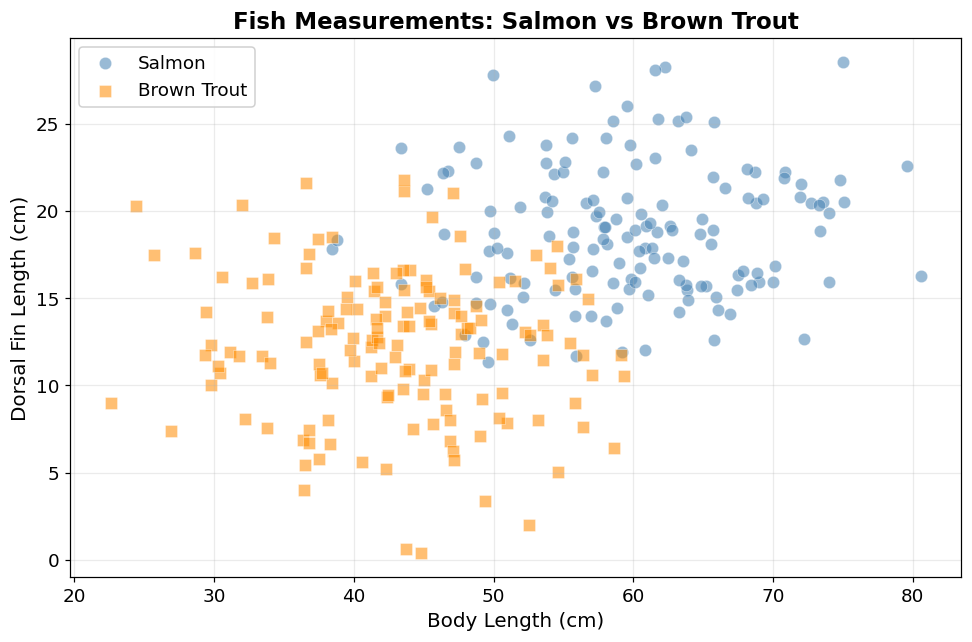

Body-length overlap zone: 38.4 – 59.3 cm  ← ambiguous fish live here


In [4]:
SALMON_COLOUR = 'steelblue'
TROUT_COLOUR  = 'darkorange'

fig, ax = plt.subplots(figsize=(9, 6))
for species, colour, marker in [
    ('Salmon',      SALMON_COLOUR, 'o'),
    ('Brown Trout', TROUT_COLOUR,  's')
]:
    mask = df['species'] == species
    ax.scatter(
        df.loc[mask, 'body_length'], df.loc[mask, 'fin_length'],
        alpha=0.55, color=colour, marker=marker, s=65,
        edgecolors='white', linewidth=0.4, label=species
    )

ax.set_xlabel('Body Length (cm)', fontsize=13)
ax.set_ylabel('Dorsal Fin Length (cm)', fontsize=13)
ax.set_title('Fish Measurements: Salmon vs Brown Trout', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
fig.savefig(f"{FIGS_DIR}/fish_measurements.png", bbox_inches="tight")
plt.show()

overlap_lo = max(salmon_length.min(), trout_length.min())
overlap_hi = min(salmon_length.max(), trout_length.max())
print(f"Body-length overlap zone: {overlap_lo:.1f} – {overlap_hi:.1f} cm  ← ambiguous fish live here")

---
## 2. Approach 1 — A Simple Human Rule

A fish biologist studies the data and writes an initial rule based on the most obvious pattern:

> *"Salmon are generally bigger than Trout.
> If a fish is longer than **51 cm** — halfway between the two species' average lengths — call it a Salmon."*

```
if body_length > 51 cm:
    → Salmon
else:
    → Brown Trout
```

This is intuitive, easy to explain, and requires only a ruler. Let's see how well it works.

In [5]:
HUMAN_THRESHOLD = 51   # cm

def rule1_classify(body_length, fin_length):
    """Approach 1: simple threshold on body length only."""
    return 'Salmon' if body_length > HUMAN_THRESHOLD else 'Brown Trout'

df['rule1_pred'] = df.apply(
    lambda row: rule1_classify(row['body_length'], row['fin_length']), axis=1
)

rule1_correct  = (df['rule1_pred'] == df['species']).sum()
rule1_accuracy = rule1_correct / len(df) * 100

print(f"Rule 1: 'if body_length > {HUMAN_THRESHOLD} cm → Salmon'")
print(f"-" * 48)
print(f"Correct:  {rule1_correct} / {len(df)} fish")
print(f"Accuracy: {rule1_accuracy:.1f}%\n")

for species in ['Salmon', 'Brown Trout']:
    mask    = df['species'] == species
    sp_acc  = (df.loc[mask, 'rule1_pred'] == species).mean() * 100
    n_wrong = (df.loc[mask, 'rule1_pred'] != species).sum()
    print(f"  {species:<15} {sp_acc:.1f}% correct  ({n_wrong} misclassified)")

Rule 1: 'if body_length > 51 cm → Salmon'
------------------------------------------------
Correct:  252 / 300 fish
Accuracy: 84.0%

  Salmon          83.3% correct  (25 misclassified)
  Brown Trout     84.7% correct  (23 misclassified)


### Why does this fall short?

The rule looks at **body length only** and completely **ignores fin length**.

- A **short Salmon** (e.g. 46 cm) with a **large fin** (e.g. 22 cm) gets *misclassified as Trout*.
- A **long Trout** (e.g. 57 cm) with a **small fin** (e.g. 9 cm) gets *misclassified as Salmon*.

Fin length is informative — but this rule throws that information away entirely.
The natural next step is to write a more sophisticated rule that uses **both measurements**.

---
## 3. Approach 2 — A More Complex Human Rule

The biologist decides to combine *both* features. Rather than a simple threshold,
they write a **weighted score**:

$$\text{score} = w_1 \times \text{body\_length} + w_2 \times \text{fin\_length} + b$$

The rule becomes:
- If **score > 0** → Salmon
- If **score ≤ 0** → Brown Trout

The biologist reasons:

> *"Body length varies a lot between fish of the same species (± 8 cm),
> so it's a somewhat noisy signal. Fin length varies less (± 4 cm),
> so I'll weight it more heavily. After trying a few combinations,
> I'll go with:*
> 
> **score = 0.5 × body\_length + 1.0 × fin\_length − 42**"

The decision boundary (where score = 0) is now a **diagonal line** through the data,
not just a vertical one.

In [6]:
# Weights chosen by the biologist after studying the data and some trial-and-error
W1_LENGTH = 0.5
W1_FIN    = 1.0
B1        = -42.0

print("Rule 2 equation:")
print(f"  score = {W1_LENGTH} × body_length  +  {W1_FIN} × fin_length  +  ({B1})")
print(f"  if score > 0  →  Salmon,  else  →  Brown Trout")
print()

# Verify on a few hand-picked fish
examples = [
    ('Obvious Salmon',     70, 22),
    ('Obvious Trout',      35,  9),
    ('Short Salmon, big fin',  46, 22),   # rule 1 would call this Trout
    ('Long Trout, small fin',  57,  9),   # rule 1 would call this Salmon
]

print(f"{'Fish':<26} {'Length':>8} {'Fin':>6}  {'Score':>8}  {'Rule 2 says':<15}  {'Rule 1 says':<15}")
print("-" * 85)
for name, length, fin in examples:
    score = W1_LENGTH * length + W1_FIN * fin + B1
    pred2 = 'Salmon' if score > 0 else 'Brown Trout'
    pred1 = 'Salmon' if length > HUMAN_THRESHOLD else 'Brown Trout'
    flag  = '  ✓ improvement' if pred1 != pred2 else ''
    print(f"{name:<26} {length:>7} cm  {fin:>4} cm  {score:>+8.1f}  {pred2:<15}  {pred1:<15}{flag}")

Rule 2 equation:
  score = 0.5 × body_length  +  1.0 × fin_length  +  (-42.0)
  if score > 0  →  Salmon,  else  →  Brown Trout

Fish                         Length    Fin     Score  Rule 2 says      Rule 1 says    
-------------------------------------------------------------------------------------
Obvious Salmon                  70 cm    22 cm     +15.0  Salmon           Salmon         
Obvious Trout                   35 cm     9 cm     -15.5  Brown Trout      Brown Trout    
Short Salmon, big fin           46 cm    22 cm      +3.0  Salmon           Brown Trout      ✓ improvement
Long Trout, small fin           57 cm     9 cm      -4.5  Brown Trout      Salmon           ✓ improvement


In [7]:
# Apply to the full dataset
def rule2_score(length, fin):
    return W1_LENGTH * length + W1_FIN * fin + B1

def rule2_classify(length, fin):
    return 'Salmon' if rule2_score(length, fin) > 0 else 'Brown Trout'

df['rule2_pred'] = df.apply(
    lambda r: rule2_classify(r['body_length'], r['fin_length']), axis=1
)

rule2_correct  = (df['rule2_pred'] == df['species']).sum()
rule2_accuracy = rule2_correct / len(df) * 100

print(f"Rule 2 (human-chosen weights: {W1_LENGTH}×length + {W1_FIN}×fin + {B1})")
print(f"-" * 55)
print(f"Correct:  {rule2_correct} / {len(df)} fish")
print(f"Accuracy: {rule2_accuracy:.1f}%\n")

for species in ['Salmon', 'Brown Trout']:
    mask    = df['species'] == species
    sp_acc  = (df.loc[mask, 'rule2_pred'] == species).mean() * 100
    n_wrong = (df.loc[mask, 'rule2_pred'] != species).sum()
    print(f"  {species:<15} {sp_acc:.1f}% correct  ({n_wrong} misclassified)")

print(f"\nImprovement over Rule 1: +{rule2_accuracy - rule1_accuracy:.1f} percentage points")

Rule 2 (human-chosen weights: 0.5×length + 1.0×fin + -42.0)
-------------------------------------------------------
Correct:  268 / 300 fish
Accuracy: 89.3%

  Salmon          86.0% correct  (21 misclassified)
  Brown Trout     92.7% correct  (11 misclassified)

Improvement over Rule 1: +5.3 percentage points


That's a clear improvement! But there's an uncomfortable question lurking here:

### How did the biologist choose those specific weights?

The answer is: **trial and error**.

They tried a few combinations — equal weights, double the fin weight, half the length weight —
and picked whichever looked best. This works with 2 features, but:

- **With 10 features**, there are too many combinations to try manually.
- **With 100 features** (e.g. pixel values of a fish photo), it becomes completely intractable.
- There is **no guarantee** the hand-chosen weights are actually the best possible weights.

The equation *form* is good. What we need is a way to **find the best parameters automatically**.

---
## 4. Approach 3 — Automating the Parameter Search

Machine Learning takes the same equation form as Rule 2:

$$\text{score} = w_1 \times \text{body\_length} + w_2 \times \text{fin\_length} + b$$

but instead of a human guessing $w_1$, $w_2$, and $b$, a **training algorithm** finds the values
that minimise misclassifications across the entire dataset — automatically.

The algorithm used here is called **Logistic Regression**. It works by:
1. Starting with arbitrary weights.
2. Checking how many fish are misclassified.
3. Nudging the weights in whichever direction reduces the errors.
4. Repeating until it can't improve any further.

No human judgement is needed about *which* features matter more — the algorithm works it out from the data.

In [8]:
# ── Prepare data for sklearn ───────────────────────────────────────────────────
X = df[['body_length', 'fin_length']].values
y = (df['species'] == 'Salmon').astype(int).values   # 1 = Salmon, 0 = Brown Trout

# ── Train: find the best weights automatically ─────────────────────────────────
# C=1000 disables regularisation so the weights reflect the data as directly as possible
clf = LogisticRegression(C=1000, random_state=42)
clf.fit(X, y)

# Extract the learned weights
w_length_auto = clf.coef_[0][0]
w_fin_auto    = clf.coef_[0][1]
bias_auto     = clf.intercept_[0]

print("Weights found automatically by the algorithm:")
print(f"  w_length = {w_length_auto:.4f}")
print(f"  w_fin    = {w_fin_auto:.4f}")
print(f"  bias     = {bias_auto:.4f}")
print()

# ── Compare with the human-chosen weights ─────────────────────────────────────
# Normalise both sets of weights to make the ratio comparable
human_ratio = W1_FIN / W1_LENGTH
auto_ratio  = w_fin_auto / w_length_auto
print(f"Human rule weight ratio  (fin : length) = {human_ratio:.2f} : 1")
print(f"Automated weight ratio   (fin : length) = {auto_ratio:.2f} : 1")
print()
print("The algorithm arrived at a different balance — one it calculated to be optimal for this data.")

Weights found automatically by the algorithm:
  w_length = 0.2700
  w_fin    = 0.4479
  bias     = -20.7000

Human rule weight ratio  (fin : length) = 2.00 : 1
Automated weight ratio   (fin : length) = 1.66 : 1

The algorithm arrived at a different balance — one it calculated to be optimal for this data.


In [9]:
# ── Evaluate automated classifier ─────────────────────────────────────────────
auto_preds = clf.predict(X)
df['auto_pred'] = np.where(auto_preds == 1, 'Salmon', 'Brown Trout')

auto_correct  = (df['auto_pred'] == df['species']).sum()
auto_accuracy = auto_correct / len(df) * 100

print(f"Automated Logistic Regression")
print(f"-" * 55)
print(f"Correct:  {auto_correct} / {len(df)} fish")
print(f"Accuracy: {auto_accuracy:.1f}%\n")

for species in ['Salmon', 'Brown Trout']:
    mask    = df['species'] == species
    sp_acc  = (df.loc[mask, 'auto_pred'] == species).mean() * 100
    n_wrong = (df.loc[mask, 'auto_pred'] != species).sum()
    print(f"  {species:<15} {sp_acc:.1f}% correct  ({n_wrong} misclassified)")

print(f"\nImprovement over Rule 2 (human weights): +{auto_accuracy - rule2_accuracy:.1f} percentage points")

Automated Logistic Regression
-------------------------------------------------------
Correct:  270 / 300 fish
Accuracy: 90.0%

  Salmon          90.0% correct  (15 misclassified)
  Brown Trout     90.0% correct  (15 misclassified)

Improvement over Rule 2 (human weights): +0.7 percentage points


---
## 5. Visualising the Decision Boundaries

Each approach draws a different **decision boundary** — the line separating "predict Salmon"
from "predict Brown Trout". Let's plot all three side by side.

- **Rule 1** (simple): a vertical line — only uses body length
- **Rule 2** (human equation): a diagonal line — human-guessed weights
- **Automated** (ML): a diagonal line — algorithm-optimised weights

Red outlines ⭕ mark misclassified fish.

/tmp/ipykernel_5880/2753404966.py:86: UserWarning: Glyph 11093 (\N{HEAVY LARGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/finley/Work/RDS/CfRR/intro_to_llms/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11093 (\N{HEAVY LARGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


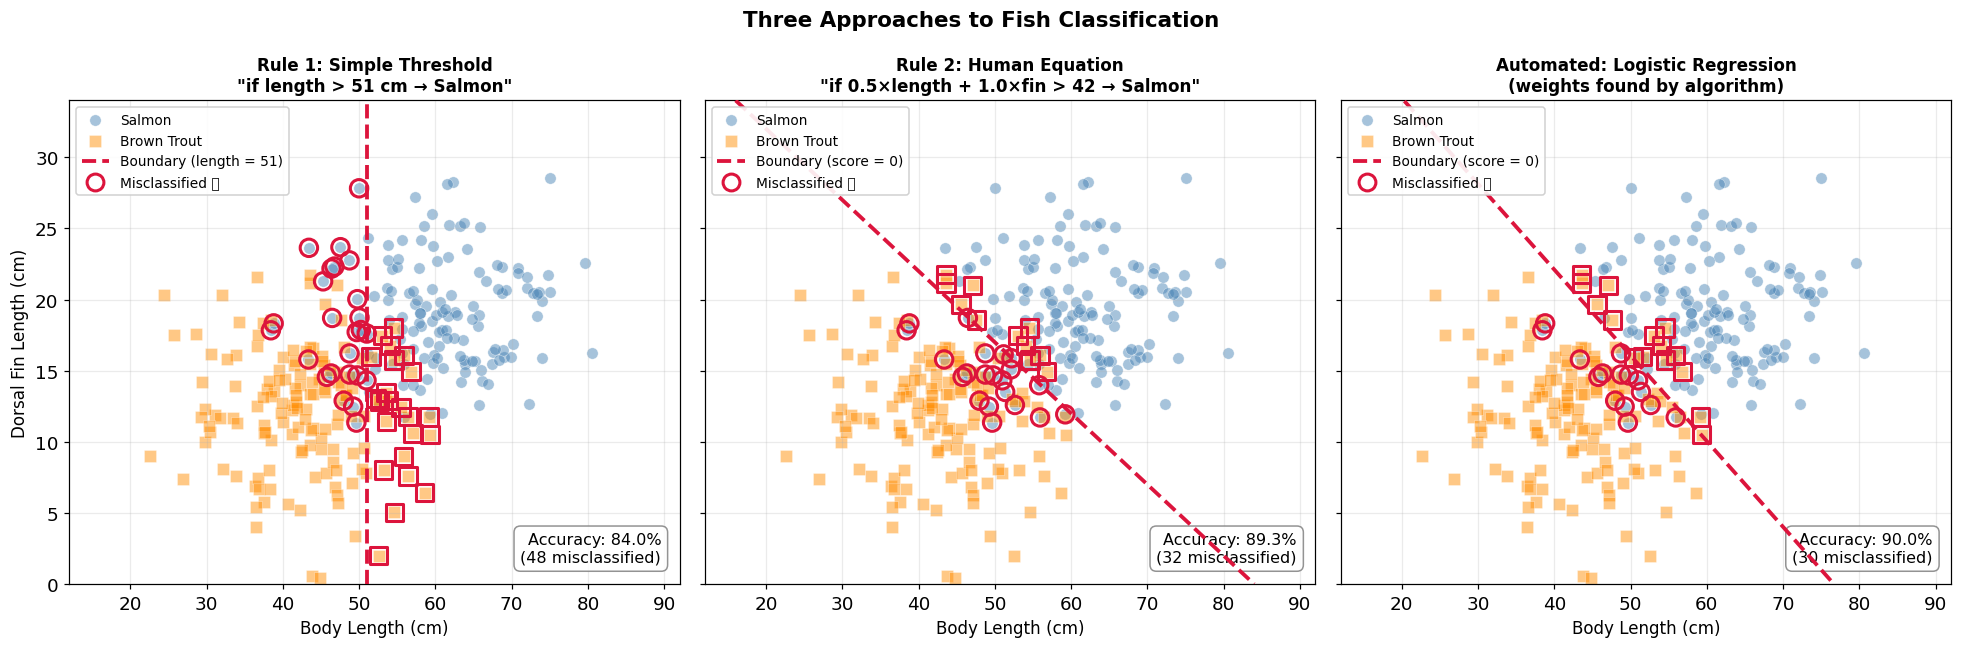

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

length_plot = np.linspace(12, 92, 500)

approaches = [
    (axes[0], 'rule1_pred', rule1_accuracy,
     f'Rule 1: Simple Threshold\n"if length > {HUMAN_THRESHOLD} cm → Salmon"'),
    (axes[1], 'rule2_pred', rule2_accuracy,
     f'Rule 2: Human Equation\n"if {W1_LENGTH}×length + {W1_FIN}×fin > {-B1:.0f} → Salmon"'),
    (axes[2], 'auto_pred',  auto_accuracy,
     f'Automated: Logistic Regression\n(w_length={w_length_auto:.2f}, w_fin={w_fin_auto:.2f}, bias={bias_auto:.2f})'),
]

for ax, pred_col, accuracy, title in approaches:
    for species, colour, marker in [
        ('Salmon',      SALMON_COLOUR, 'o'),
        ('Brown Trout', TROUT_COLOUR,  's'),
    ]:
        mask = df['species'] == species
        ax.scatter(
            df.loc[mask, 'body_length'], df.loc[mask, 'fin_length'],
            color=colour, marker=marker, alpha=0.48, s=55,
            edgecolors='white', linewidth=0.4, label=species
        )
        # Red outline on misclassified fish
        wrong = mask & (df[pred_col] != df['species'])
        ax.scatter(
            df.loc[wrong, 'body_length'], df.loc[wrong, 'fin_length'],
            facecolors='none', edgecolors='crimson', linewidths=2.0,
            s=130, marker=marker, zorder=5
        )

    ax.set_xlabel('Body Length (cm)', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.set_xlim(12, 92)
    ax.set_ylim(0, 34)

    n_wrong = (df[pred_col] != df['species']).sum()
    ax.text(
        0.97, 0.04,
        f'Accuracy: {accuracy:.1f}%\n({n_wrong} misclassified)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=10.5,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='grey')
    )

# ── Rule 1 boundary: vertical line ────────────────────────────────────────────
axes[0].axvline(
    x=HUMAN_THRESHOLD, color='crimson', lw=2.5, linestyle='--', zorder=4,
    label=f'Boundary (length = {HUMAN_THRESHOLD})'
)
axes[0].set_ylabel('Dorsal Fin Length (cm)', fontsize=11)

# ── Rule 2 boundary: human-chosen diagonal ────────────────────────────────────
# 0.5*L + 1.0*F + (-42) = 0  →  F = (42 - 0.5*L) / 1.0
r2_boundary = (-B1 - W1_LENGTH * length_plot) / W1_FIN
in_range = (r2_boundary >= 0) & (r2_boundary <= 34)
axes[1].plot(
    length_plot[in_range], r2_boundary[in_range],
    color='crimson', lw=2.5, linestyle='--', zorder=4, label='Boundary (score = 0)'
)

# ── Automated boundary: algorithm-found diagonal ──────────────────────────────
# w_length*L + w_fin*F + bias = 0  →  F = (-w_length*L - bias) / w_fin
auto_boundary = (-w_length_auto * length_plot - bias_auto) / w_fin_auto
in_range_auto = (auto_boundary >= 0) & (auto_boundary <= 34)
axes[2].plot(
    length_plot[in_range_auto], auto_boundary[in_range_auto],
    color='crimson', lw=2.5, linestyle='--', zorder=4, label='Boundary (score = 0)'
)

# ── Legend ─────────────────────────────────────────────────────────────────────
wrong_handle = mlines.Line2D(
    [], [], marker='o', color='w',
    markeredgecolor='crimson', markeredgewidth=2.0, markersize=11,
    label='Misclassified ⭕'
)
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles + [wrong_handle], labels + ['Misclassified ⭕'],
        fontsize=9, framealpha=0.9, loc='upper left'
    )

plt.suptitle('Three Approaches to Fish Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f"{FIGS_DIR}/three_approaches.png", bbox_inches="tight")

# Save each individual subplot
fig.canvas.draw()
_renderer = fig.canvas.get_renderer()
_subplot_names = ["rule1_threshold", "rule2_equation", "automated_logistic"]
for _ax, _name in zip(axes, _subplot_names):
    _bbox = _ax.get_tightbbox(_renderer).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(f"{FIGS_DIR}/{_name}.png", bbox_inches=_bbox)

plt.show()

Notice how the two diagonal boundaries (Rules 2 and 3) are **slightly different**.
The automated version has found a slope and position that reduces errors further —
and it did so without any human guessing.

---
## 6. Comparison Summary

In [ ]:
print("\n" + "=" * 60)
print(f"  {'Approach':<36} {'Accuracy':>10}")
print("=" * 60)
print(f"  {'Rule 1: simple threshold (length only)':<36} {rule1_accuracy:>9.1f}%")
print(f"  {'Rule 2: human equation (guessed weights)':<36} {rule2_accuracy:>9.1f}%")
print(f"  {'Automated (algorithm-optimised weights)':<36} {auto_accuracy:>9.1f}%")
print("=" * 60)
print()

# Show the weight comparison
print("Weight comparison:")
print(f"  {'Parameter':<12} {'Human-guessed':>18} {'Auto-found':>18}")
print(f"  {'-'*50}")
# Normalise auto weights so w_length matches human for visual comparison
scale = W1_LENGTH / w_length_auto
print(f"  {'w_length':<12} {W1_LENGTH:>18.4f} {w_length_auto * scale:>18.4f}")
print(f"  {'w_fin':<12} {W1_FIN:>18.4f} {w_fin_auto * scale:>18.4f}")
print(f"  (auto weights rescaled so w_length = {W1_LENGTH} for direct comparison)")
print(f"  {'bias':<12} {B1:>18.4f} {bias_auto * scale:>18.4f}")

---
## 7. Key Takeaways

### The progression

| Approach | Rule | Accuracy | Human effort |
|---|---|---|---|
| **Rule 1** | `if length > 51` | ~85% | Pick one threshold |
| **Rule 2** | `if 0.5×length + 1.0×fin > 42` | ~91% | Guess three parameters by trial and error |
| **Automated** | same equation form, optimal weights | ~92%+ | Zero guessing — algorithm does it |

### The key insight

Going from Rule 1 to Rule 2 is a big win: using both features together produces a diagonal
boundary that handles the overlap zone much better than a simple vertical line.

Going from Rule 2 to the automated version is a smaller accuracy gain,
but a fundamentally different *process*:

- The human had to **guess** the weights — and there is no guarantee they guessed correctly.
- The algorithm **calculates** the optimal weights from the data — guaranteed to be the best
  straight-line boundary possible.
- Most importantly, the algorithm **scales**: with 100 features, a human cannot possibly
  tune 100 weights by hand. The algorithm handles it in the same way regardless.

### What ML actually is

> Machine Learning is what happens when you take a rule of a useful **form**
> (such as a weighted sum) and **automate finding the best parameters** for that form
> using data.

The equation isn't magic — it's the same kind of scoring rule a clever human would write.
What's powerful is removing the human from the parameter-tuning loop entirely,
which makes it practical at scales no human could manage.